# Introducción a la Regresión lineal (simple)

In [1]:
import matplotlib.pyplot as plt



 Supondremos que un amigo nos invita a invertir en su empresa de helados, donde dependiendo de la inversión que hagamos, recibiremos una ganancia. Para este ejemplo "x" es el dinero invertido e "y" es el dinero ganado

In [2]:
import numpy as np
x = np.array([0,6.5,13.2,18.1,24.9,28.2,36.1],)
y = np.array([6,10,17,20,25,30,35])

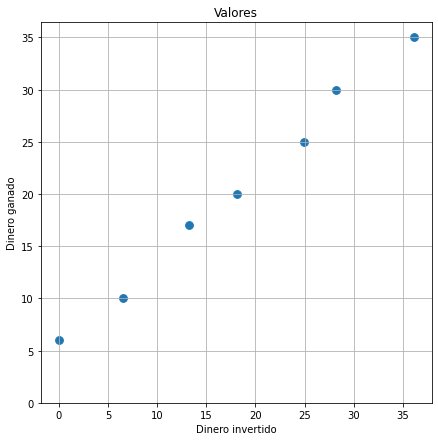

In [3]:
plt.figure(figsize=(7,7))
plt.scatter(x,y,s=60)
plt.ylim(bottom=0)
plt.title("Valores")
plt.xlabel("Dinero invertido")
plt.ylabel('Dinero ganado')

plt.grid()
plt.show()

Dinero invertido= caracteristica= variable independiente
 Dinero ganado= Objetivo=Target= Variable dependiente


Ahora imaginemos que queremos definir una operación para poder calcular la cantidad de dinero ganado como parte de la inversión para otros valores que no se encuentran en las lista anterior (correspondecia de valores de x - y).

In [11]:
x2 = np.arange(0,40)
y2 = 0.8 * x2+6

In [ ]:
primer valor cambia la pendiente , segundo valor la interseccion con el eje x

Ahora podriamos imprimir una linea que contenga las cantidades (puntos a lo largo de la línea) que podria ganar un inversionista dependiendo de la cantidad que decida invertir (en el rango de 0 a 40 pesos)

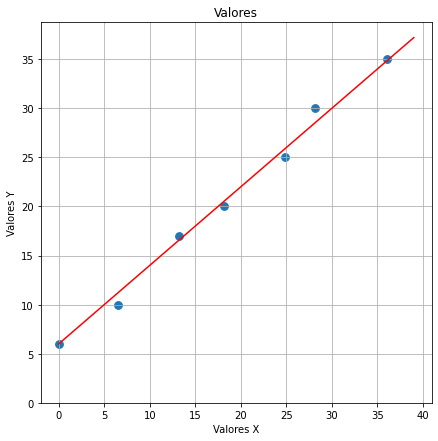

In [12]:
plt.figure(figsize=(7,7))
plt.plot(x2,y2,color='red', label="Nuestra solucion")
#s = tama;o punto
plt.scatter(x,y,s=60)
plt.ylim(bottom=0)
plt.title("Valores")
plt.xlabel("Valores X")
plt.ylabel("Valores Y")
plt.grid()
plt.show()


## función de regresión lineal

$$ \hat{y}= f(\vec{x})$$
$$ \hat{y}= \vec{w}\cdot \vec{x}+b $$
$$ \hat{y}=w_{1}x_{1}+w_{2}x_{2}+\cdots +w_{n}x_{n}+b $$

In [ ]:
prediccion=peso*feature+bias

Lo anterior podriamos representarlo mediante una función en python que permita calcular el valor de la ganancia solo ingresando la cantidad invertida

In [17]:
# función de regresión lineal simple en python
def calcular_ganancia(x):
    y=0.8*x+5
    return y


In [21]:
# pasamos valores de x a la función para probarla
print(calcular_ganancia(30))

29.0


### Regresión lineal polinomial

Supongase que adicionalmente a la variable de la cantidad que se invierte en la empresa, se toma otra variable en cuenta, por ejemplo el mes en que se hace la inversión.
Esta variable se convierte en un nuevo arreglo que denominamos x2

In [23]:
# supongamos que x es el dinero invertido
# e y es el dinero ganado
# adicionalmente x2 es la temperatura máxima alcanzada durante 7 meses
# del año inmediato anterior
#primera variable independiente
x1=np.array([0,6.5,13.2,18.1,24.9,28.2,36.1])
#segunda variable independiente
x2=np.array([22,23,24,21,10,17,8])
#tarrget/bias
y=np.array([5,10,17,20,25,30,35])

La función que nos permite representar la regresión lineal polinomial es:

$$ \hat{y}=w_{1}x_{1}+w_{2}x_{2}+\cdots +w_{n}x_{n}+b $$

Como se pude predecir, ahora la solución no será una línea que se se dibuja en un plano (como ocurrió en la regresión lineal simple), si no que será un plano que se dibujará en un espacio tridimensional (una gráfica con 3 dimensiones).
También se puede preveer, que el desafio ahora es encontrar los valores para w1, w2 y el bias b, para que una vez que se reemplacen los valores, se obtenga una "y" lo más cercano posibl a la verdad.

Entonces lo que se debe hacer es medir en todo momento, por cuanto nos estamos equivocando con la solución que proponemos.

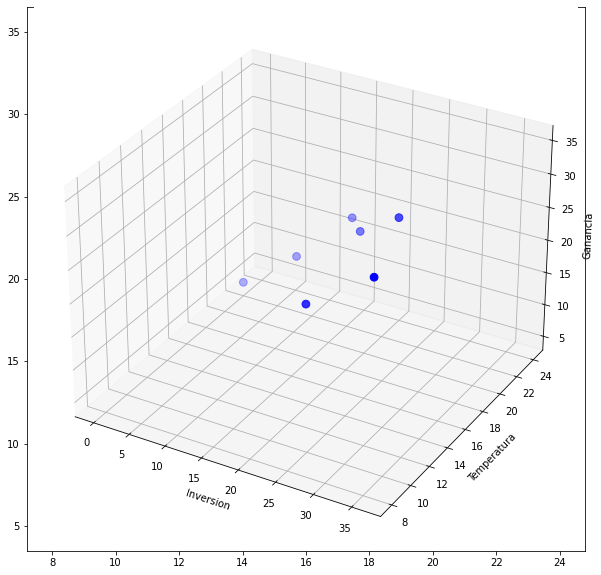

In [26]:
from mpl_toolkits import mplot3d

plt.figure(figsize=(10,10))
plt.plot(x2,y, color="red",label='Nuestra solucion')
ax=plt.axes(projection="3d")
ax.scatter3D(x1,x2,y,c="b",s=60)
ax.set_xlabel("Inversion")
ax.set_ylabel('Temperatura')
ax.set_zlabel("Ganancia")
plt.grid()
plt.show()



Supongamos que en la siguiente gráfica, la línea azul representa la solución que contiene los resultados propuestos para las ganancias por diferentes inversiones, los circulos en verde las ganancias reales que se deben dar a cada inversión y las lineas rojas representa la diferencia entre el resultado propuesto y el real![Captura%20de%20pantalla%202024-09-16%20a%20las%2022.02.09.png](attachment:Captura%20de%20pantalla%202024-09-16%20a%20las%2022.02.09.png)

En otras palabras, las lineas rojas representan el error de la propuesta con respecto a las ganancias reales.
¿Cuál de esos errores es el que debemos tomar para ajustar mejor la propuesta de solución?,
¿qué es mas conveniente, seleccionar el error más grande o el error más pequeño?

Hay una manera mas adecuada de calcular ese erorr y es mediante el error cuadrático medio.

## Error cuadrático medio

$$ MSE= \frac{1}{M}\sum_{i= 1}^{M}(real_{i}-estimado_{i})^{2} $$

El error cuadrático medio es el promedio de la diferencia de los valores reales menos los estimados elevados al cuadrado.
Y lo que se intentará es encontrar los valores para w1, w2 y b que nos den el menor error cuadrático medio.

El Error Cuadrático Medio es el criterio de evaluación más usado para problemas de regresión.
Se usa sobre todo cuando se implementa aprendizaje automático supervisado. Para cada dato histórico podremos indicar el resultado correcto.
¿Cómo se calcula?

$$ error cuadratico = (real - estimado)^{2}$$

Error real menos estimado, tiene lógica, pero, ¿por qué al cuadrado?
Simple, no queremos valores negativos, para tomar de esa manera el 0 como valor perfecto.

Otro punto a tomar en cuenta es que podriamos usar los valores absolutos de los errores, o sea, simplemente quitándoles su signo. Pero esto resultaría en una función no derivable, algo qu nos jugaría en contra en un futuro cuando apliquemos algoritmos de optimización más efectivos como el Gradiente Descendente.

Una vez que se ha calculado el error de cada uno de los puntos, se puede calcula el error medio. Para ello sumamos todos los errores y luego dividimos el resultado por la cantidad de errores (puntos) que acabamos de sumar.

## Raíz cuadrada del Error cuadrático medio

$$ RMSE= \sqrt{\frac{1}{M}\sum_{i= 1}^{M}(real_{i}-estimado_{i})^{2}} $$

El error cuadrático médio es preciso pero algo engañoso, ya que si vemos en una estimación de precios que nuestro sistema tiene un error cuadrático medio de 1 millón de dolares, tenemos que tener presente que sumamos potencias de 2, en otras palabras sumamos números que previamente elevamos al cuadrado.
Por lo que el error real, será la raíz cuadrada de ese valor, el cual pos sus siglas en inglés denominamos RMSE.

Para resumir, a la hora de visualizar puede que el RMSE nos de una sensación más realista, pero a la hora de computar, el MSE tiene una carga computacional mucho menor, por eso es que es más usado.